In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

from IPython.display import display
import toml


In [2]:
def extract_best(df):
    chosen_configurations = []
    for recall_cut in np.arange(0.9, 1.01, 0.01):
        chosen_configurations.append(df[df.Recall > recall_cut].sort_values("Query Time (microsecs)").head(1))
    df = pd.concat(chosen_configurations)
    return df


In [3]:
def extract_df(base_dir):
    full_df = []

    for file in os.listdir(base_dir):
        if file.endswith("json"):
            continue
        path = os.path.join(base_dir, file, "report.tsv")
        if not os.path.exists(path):
            print(f"{path} does not exists, skipping")
            continue
        try:
            df = pd.read_csv(path, sep="\t")
        except:
            print(f"Skipping {path}")
            continue
            
        #df['name'] = f"{(df['Memory Usage (Bytes)'].values[0] / 1024**3).round(2)} GByte"
        df['name'] = file
        config = toml.load(os.path.join(base_dir, file, "experiment_config.toml"))

        for k, v in config['indexing_parameters'].items():
            df[k] = v
        enriched_df = []
        for (i, row) in df.iterrows():
            params = config['query'][row.Subsection]
            for k,v in params.items():
                if k in row:
                    row[k+"1"] = v
                else:    
                    row[k] = v
            enriched_df.append(row)
            
        full_df.append(pd.DataFrame(enriched_df))
        
        
    if len(full_df) > 0:
        return pd.concat(full_df) 
    else:
        print("Nothing to concat!")
        return pd.DataFrame()
    


def grab_full_report(name):
    df = pd.read_csv(os.path.join(name, "report.tsv"), sep="\t")
    experiment_config_path = os.path.join(name, "experiment_config.toml")
    config = toml.load(experiment_config_path)
    enriched_df = []
    for (i, row) in df.iterrows():
        params = config['query'][row.Subsection]
        for k,v in params.items():
            if k in row:
                row[k+"1"] = v
            else:    
                row[k] = v
        enriched_df.append(row)
    return pd.DataFrame(enriched_df)

In [4]:
base_dir = "/data2/cosimorulli/log_ecir_2026/ecir_2026_inference_less_big_base_2025-10-03_15:56:37.842542/"
all_df = extract_df(base_dir)
#forward_index_size = 4313529200 # Cocondenser
forward_index_size = 13764389604 # Inference less big

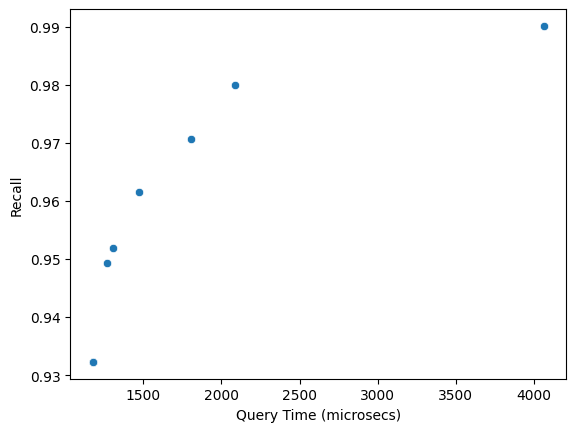

In [5]:

for mem_limit in [1.5]:
    current_df = extract_best(all_df[all_df['Memory Usage (Bytes)'] <= mem_limit * forward_index_size])

    sns.scatterplot(data=current_df, x = "Query Time (microsecs)", y="Recall")
    plt.show()

In [9]:
current_df.tail(1)

,Subsection,Query Time (microsecs),Recall,RR@10,Memory Usage (Bytes),Building Time (secs),name,centroid-fraction,clustering-algorithm,kmeans-doc-cut,...,max-fraction,min-cluster-size,n-postings,pruning-strategy,summary-energy,value-type,query-cut,heap-factor,knn1,first_sorted
20,combination_21,4061,0.990129,0.387799,18783544058,383,building_combination_9_2025-10-03_23:52:33,0.1,random-kmeans-inverted-index-approx,15,...,3.0,10,6000,global-threshold,0.5,f16,8,0.9,0,True


In [7]:
18783544058 / 1024**3

17.493538612499833

In [11]:
extract_best(pd.read_csv("/home/cosimorulli/next_develop_seismic/seismic_private/grid_search_inference_less_partitioned_f16_2025-10-08_17:32:39.087706/building_combination_0_2025-10-08_17:32:39/report.tsv", sep="\t"))

,Subsection,Query Time (microsecs),Recall,RR@10,Memory Usage (Bytes),Building Time (secs)
7,combination_8,1446,0.907894,0.373927,16264778733,464
14,combination_15,1955,0.972163,0.385288,16264778733,464
14,combination_15,1955,0.972163,0.385288,16264778733,464
14,combination_15,1955,0.972163,0.385288,16264778733,464
14,combination_15,1955,0.972163,0.385288,16264778733,464
14,combination_15,1955,0.972163,0.385288,16264778733,464
14,combination_15,1955,0.972163,0.385288,16264778733,464
14,combination_15,1955,0.972163,0.385288,16264778733,464
23,combination_24,2126,0.983381,0.386889,16264778733,464
36,combination_37,3775,0.990473,0.387690,16264778733,464


In [15]:
(16264778733 -  (13764389604/ 2) + 5019160268) / 1024**3

13.412669486366212